In [1]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
off = pd.read_csv('/content/drive/MyDrive/DatosLab/laserOFF(B).csv', sep=',')
on = pd.read_csv('/content/drive/MyDrive/DatosLab/laserON(B).csv', sep=',')

-73.434105 1427
-72.6987 1398


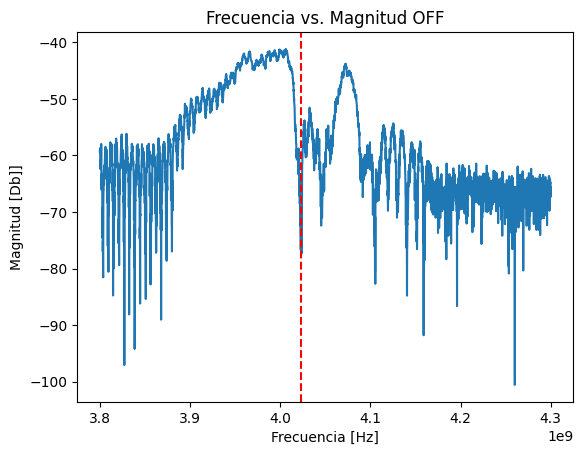

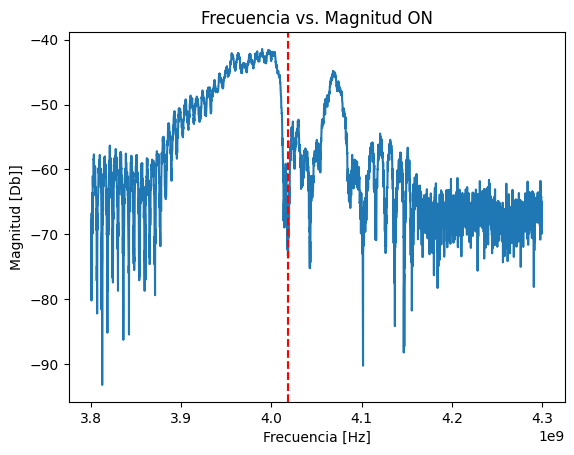

25277058141.242626
25248587457.81947
0.02847068342315674


In [3]:
import matplotlib.pyplot as plt
import numpy as np

frecuencias_off = off['Freq(Hz)']
s12_deg_off = off['S12(DEG)']
s21_deg_off = off['S21(DEG)']

s12_mag_off = off['S12(DB)']
s21_mag_off = off['S21(DB)']

frecuencias_on = on['Freq(Hz)']
s12_deg_on = on['S12(DEG)']
s21_deg_on = on['S21(DEG)']

s12_mag_on = on['S12(DB)']
s21_mag_on = on['S21(DB)']

# escoger rango para encontrar el punto mínimo

min = 0
max = 0

for i in range(len(frecuencias_on)):
    if frecuencias_on[i] == 3.95e9:
        min = i
    elif frecuencias_on[i] == 4.03e9:
        max = i

rango_off = s12_mag_off[min:max]
rango_on = s12_mag_on[min:max]

mag_max_off = 0
i_max_off = 0
i_max_on = 0
mag_max_on = 0

for i in range(1,len(rango_off)-1):
    if rango_off.iloc[i-1] > rango_off.iloc[i]:
        if rango_off.iloc[i] < rango_off.iloc[i+1]:
            if mag_max_off > rango_off.iloc[i]:
                mag_max_off = rango_off.iloc[i]
                i_max_off = len(s12_mag_off[0:min]) + i


for i in range(1,len(rango_on)-1):
    if rango_on.iloc[i-1] > rango_on.iloc[i]:
        if rango_on.iloc[i] < rango_on.iloc[i+1]:
            if mag_max_on > rango_on.iloc[i]:
                mag_max_on = rango_on.iloc[i]
                i_max_on = len(s12_mag_on[0:min]) + i

print(mag_max_off, i_max_off)
print(mag_max_on, i_max_on)

plt.plot(frecuencias_off, s21_mag_off)
plt.axvline(x = frecuencias_off[i_max_off], color = 'red',linestyle='--')
plt.title('Frecuencia vs. Magnitud OFF')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [Db]]')
plt.show()

plt.plot(frecuencias_on, s21_mag_on)
plt.axvline(x = frecuencias_on[i_max_on], color = 'red',linestyle='--')
plt.title('Frecuencia vs. Magnitud ON')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [Db]]')
plt.show()

wFMR_on = frecuencias_on[i_max_on]*2*np.pi
wFMR_off = frecuencias_off[i_max_off]*2*np.pi

print(wFMR_off)
print(wFMR_on)

print(np.abs(wFMR_on-wFMR_off)*1e-9)



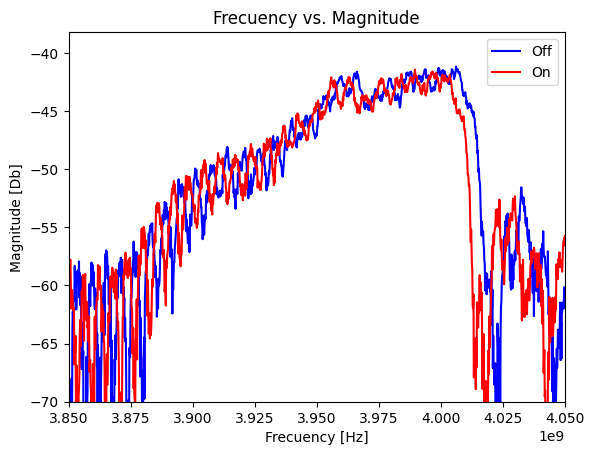

In [14]:
plt.plot(frecuencias_off, s21_mag_off, label ='Off', color = 'blue')
plt.plot(frecuencias_on, s21_mag_on,label='On', color = 'red')
plt.title('Frecuency vs. Magnitude')
plt.xlabel('Frecuency [Hz]')
plt.ylabel('Magnitude [Db]')
plt.xlim(3.85e9,4.05e9)
plt.ylim(-70,None)
plt.legend()
plt.show()



$\omega_{FMR} = \sqrt{\omega_H(\omega_H + \omega_M)}$

$\omega_M = \frac{\omega_{FMR}^2 - \omega_H^2}{\omega_H}$

$\omega_M = \gamma \mu_0 M_S = \gamma \mu_0 [M_{S,RT}-\eta (T-T_{RT})]$

$\frac{\omega_{FMR}^2 - \omega_H^2}{\omega_H} = \gamma \mu_0 [M_{S,RT}-\eta (T-T_{RT})]$

$T = -\frac{1}{\gamma \mu_0 \eta}\left[\frac{\omega_{FMR}^2 - \omega_H^2}{\omega_H} -\gamma \mu_0 M_{S,RT}\right] + T_{RT}$

In [5]:
# Para encontrar la temperatura asociada a cada wFMR y después el cambio de temperatura

H0 = 770 #[Oe]
gamma = 2.8e-3 * (1e9) #[Hz/Oe]
deltaH = 0.5 #[Oe]
mu0 = 1

Ms_roomtemp = 1759.3 #[G]
eta = 3.933 #[G/Kelvin]
T_room = 298 #[Kelvin]

wH = gamma*mu0*H0

def temperatura(w):
  w = w/(2*np.pi)
  T = -(1/(gamma*mu0*eta))*(((w**2-wH**2)/wH)-gamma*mu0*Ms_roomtemp) + T_room
  return T

T_off = temperatura(wFMR_off)
T_on = temperatura(wFMR_on)

def omegaFMR(T):
    Ms = Ms_roomtemp - eta*(T-T_room)
    wM = gamma*mu0*Ms
    w = np.sqrt(wH*(wH+wM))
    return w*2*np.pi

print(omegaFMR(T_off))
print(omegaFMR(T_on))

print('La temperatura con el láser apagado es:')
print(T_off, 'K')
print('La temperatura con el láser encendido es:')
print(T_on, 'K')
print('El cambio en la temperatura es:')
print(np.abs(T_on-T_off))

25277058141.242626
25248587457.81947
La temperatura con el láser apagado es:
259.4450758680701 K
La temperatura con el láser encendido es:
260.97976102507175 K
El cambio en la temperatura es:
1.534685157001661
